In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import cv2

# Scaling Transformation

In [4]:
points=np.array([
    [0,0],
    [1,0],
    [1,1],
    [0,1],
    [0,0]
])

In [5]:
#Scaling Matrix
S=np.array([[2,0],[0,1.5]])
S

array([[2. , 0. ],
       [0. , 1.5]])

In [6]:
def transform(points,matrix):
  return(matrix @ points.T).T

  #s.dot(p)    OR     s@p

In [7]:
scaled=transform(points,S)

In [8]:
print(scaled)

[[0.  0. ]
 [2.  0. ]
 [2.  1.5]
 [0.  1.5]
 [0.  0. ]]


In [9]:
def plot_transform(original,transformed,title):
  plt.figure(figsize=(6,6))
  plt.plot(original[:,0],original[:,1],label="Original",linewidth=2)
  plt.plot(transformed[:,0],transformed[:,1],label="Transformed",linewidth=2)
  plt.axhline(0,color="black",linewidth=1)
  plt.axvline(0,color="black",linewidth=1)
  plt.legend()
  plt.title(title)
  plt.grid()
  plt.show()

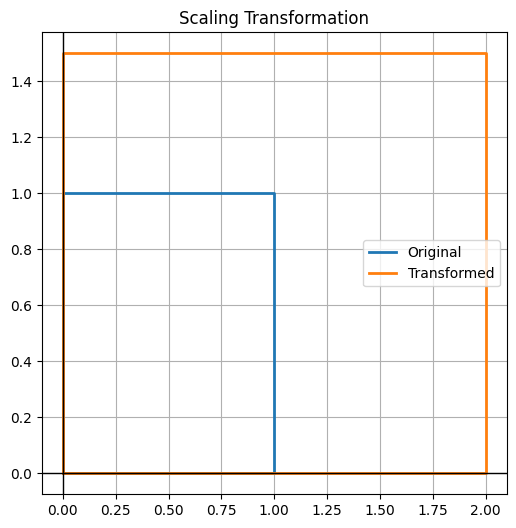

In [10]:
plot_transform(points,scaled,"Scaling Transformation")

# Scaling an image-Demo

In [13]:
from google.colab.patches import cv2_imshow

image=cv2.imread('/content/drive/MyDrive/Deep Learning/IMAGE AUGMENTATION/cat.jpg')
s=np.array([[2,0],[0,1.5]])

height, width=image.shape[:2]
scaled_image=cv2.warpAffine(image,
                            np.vstack([S,[0,0]]).T[:2],
                             (int(width*2),int(height*1.5)))


cv2_imshow(image)
cv2_imshow(scaled_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

Output hidden; open in https://colab.research.google.com to view.

# Rotation(45 degrees)

In [14]:
points

array([[0, 0],
       [1, 0],
       [1, 1],
       [0, 1],
       [0, 0]])

In [15]:
points=np.array([
    [0,0],
    [1,0],
    [1,1],
    [0,1],
    [0,0]
])

In [16]:
theta=np.pi/4

In [17]:
theta

0.7853981633974483

In [18]:
R=np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])

In [19]:
R

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

In [20]:
rotated=transform(points,R)

In [21]:
rotated

array([[ 0.00000000e+00,  0.00000000e+00],
       [ 7.07106781e-01,  7.07106781e-01],
       [ 1.11022302e-16,  1.41421356e+00],
       [-7.07106781e-01,  7.07106781e-01],
       [ 0.00000000e+00,  0.00000000e+00]])

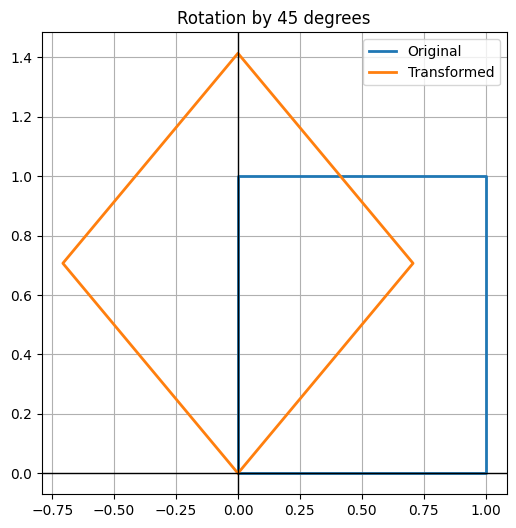

In [22]:
plot_transform(points,rotated,"Rotation by 45 degrees")

# Rotating an Image

In [23]:
import random
from scipy.ndimage import rotate

In [24]:
def rotate_image(image,angle_range=(-15,15)):
  """Rotate image by random angle"""
  angle=random.uniform(angle_range[0],angle_range[1])
  rotated=rotate(image,angle,reshape=False,cval=0)
  return rotated.astype(np.uint8)

In [25]:
image=cv2.imread('/content/drive/MyDrive/Deep Learning/IMAGE AUGMENTATION/cat.jpg')
rotated_img=rotate_image(image)

In [26]:
cv2.imshow('Original',image)
cv2.imshow('Rotated',rotated_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

DisabledFunctionError: cv2.imshow() is disabled in Colab, because it causes Jupyter sessions
to crash; see https://github.com/jupyter/notebook/issues/3935.
As a substitution, consider using
  from google.colab.patches import cv2_imshow
